conjunto de datos con datos meteorológicos de EE. UU.

columnas --> Location, Date_Time, Temperature, Humidity, Precipitation, Wind Speed.

Cree un índice jerárquico con 2 niveles: Ciudad y Fecha.

Explique cómo esta estructura puede optimizar el análisis de datos para las tendencias meteorológicas a nivel de ciudad y fecha.

Filtrar los días con temperaturas superiores a 30°.

Explique cómo el filtrado, en combinación con la indexación jerárquica, puede utilizarse para aislar y analizar rápidamente los patrones de olas de calor en ubicaciones geográficas específicas.

In [99]:
# === Librerías ===

import pandas as pd
import requests, zipfile, io

import matplotlib.pyplot as plt
import seaborn as sns

# Mostrar floats con 2 decimales
pd.set_option('display.float_format', '{:.2f}'.format)


## === Download and import the Wheather Data dataset.===

# Download and read the CSV from the ZIP file.

# URL of the ZIP (raw)
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D1%20-%20Data%20Visualization,%20Matplot/Weather%20Data.zip"

# Download the ZIP file
r = requests.get(url)
r.raise_for_status()

# Open ZIP from memory
zip_file = zipfile.ZipFile(io.BytesIO(r.content))

# List files within the ZIP
print("Files in zip:", zip_file.namelist())

# Read the CSV file inside the ZIP
csv_file_name = zip_file.namelist()[0]  # 1° file
df = pd.read_csv(zip_file.open(csv_file_name))



Files in zip: ['weather_data.csv']


In [100]:
# Formateo y conversión de fecha

df['Location'] =  df['Location'].astype('string').str.lower()  #formateo a string en minuscula

# Convertir Date_Time a datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'], errors='coerce')

# Crear columna Date (solo fecha, hora en 00:00)
df['Date'] = df['Date_Time'].dt.normalize()

# === Resumen diario por ciudad (MultiIndex) === proxy a index jerarquizado
daily = df.groupby(['Location','Date']).agg({
    'Temperature_C': 'max',       # Máxima diaria
    'Humidity_pct': 'mean',       # Promedio diario
    'Precipitation_mm': 'sum',    # Total diario
    'Wind_Speed_kmh': 'mean'      # Promedio diario
}).sort_index()


# 4️⃣ Crear MultiIndex (Ciudad, Fecha) --> Ya existe en el groupby, NO ES NECESARIO el codigo de abajo
#daily = daily.set_index(['Location', 'Date']).sort_index()


# === Días con temperatura >30°C ===
hot_days = daily[daily['Temperature_C'] > 30]


# === Olas de calor (≥3 días consecutivos >30°C por ciudad) ===

# Booleano por ciudad: True si día > 30°C
hot_bool = daily['Temperature_C'] > 30

# Rolling de 3 días por ciudad
heatwave = hot_bool.groupby(level='Location').rolling(3, min_periods=3).sum()

# Eliminar el nivel extra agregado por rolling
heatwave.index = heatwave.index.droplevel(0)

# Filtrar filas de daily donde hubo ola de calor
heatwave_days = daily[heatwave >= 3]



In [101]:
#compruebo rapido que esta en celsius
print(df['Temperature_C'].min(), df['Temperature_C'].max())


-19.96931109358452 39.99980055990208


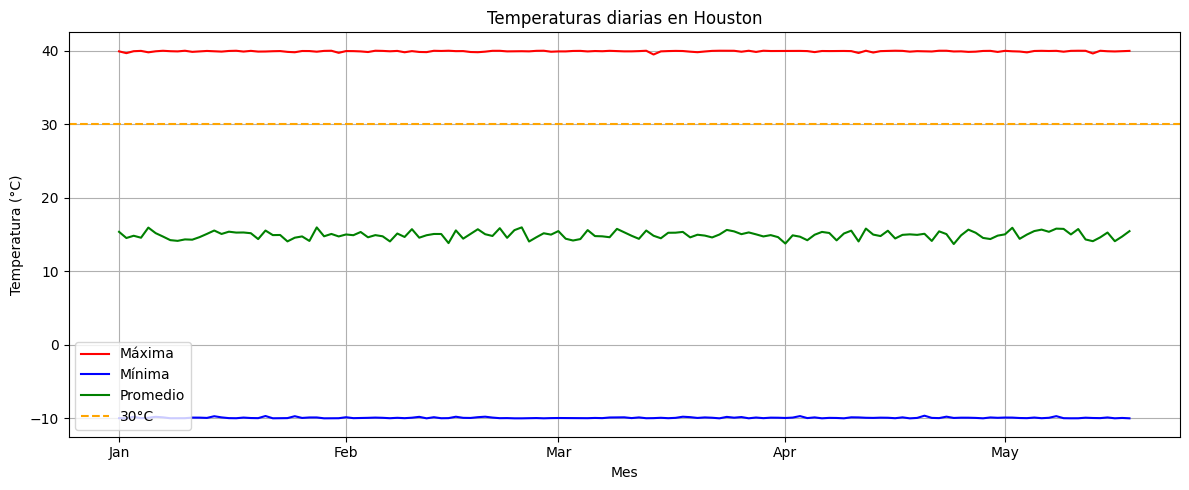

In [112]:
# === Visualización 1: temperatura diaria de una ciudad ===

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

city = 'houston'

# Agrupar por día para obtener min, max y promedio
daily_stats = df[df['Location'] == city].groupby(df['Date_Time'].dt.normalize()).agg({
    'Temperature_C': ['min', 'max', 'mean']
})
daily_stats.columns = ['Temp_Min', 'Temp_Max', 'Temp_Mean']

# Graficar
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(daily_stats.index, daily_stats['Temp_Max'], label='Máxima', color='red')
ax.plot(daily_stats.index, daily_stats['Temp_Min'], label='Mínima', color='blue')
ax.plot(daily_stats.index, daily_stats['Temp_Mean'], label='Promedio', color='green')
ax.axhline(30, color='orange', linestyle='--', label='30°C')

# Formatear eje X para mostrar solo meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Ene, Feb, Mar, ...

plt.title(f"Temperaturas diarias en {city.title()}")
plt.xlabel("Mes")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Eso no es realista climáticamente. Probablemente:
# Este dataset es simulado, no refleja datos reales.
# O las temperaturas están ya escaladas, normalizadas o generadas aleatoriamente para entrenamiento/ejercicios de análisis de datos.


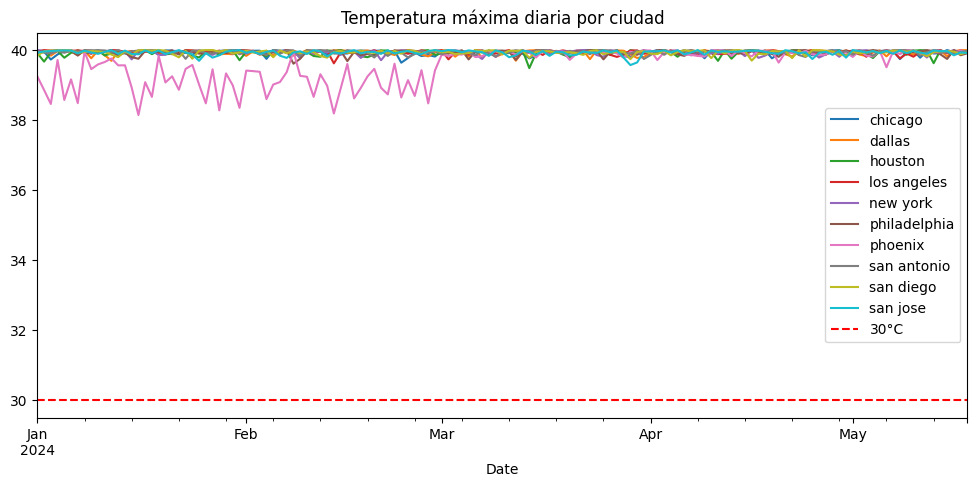

In [113]:
# === Visualización 2: comparación entre ciudades ===

daily['Temperature_C'].unstack('Location').plot(
    figsize=(12,5),
    title="Temperatura máxima diaria por ciudad"
)
plt.axhline(30, color='red', linestyle='--', label='30°C')
plt.legend()
plt.show()

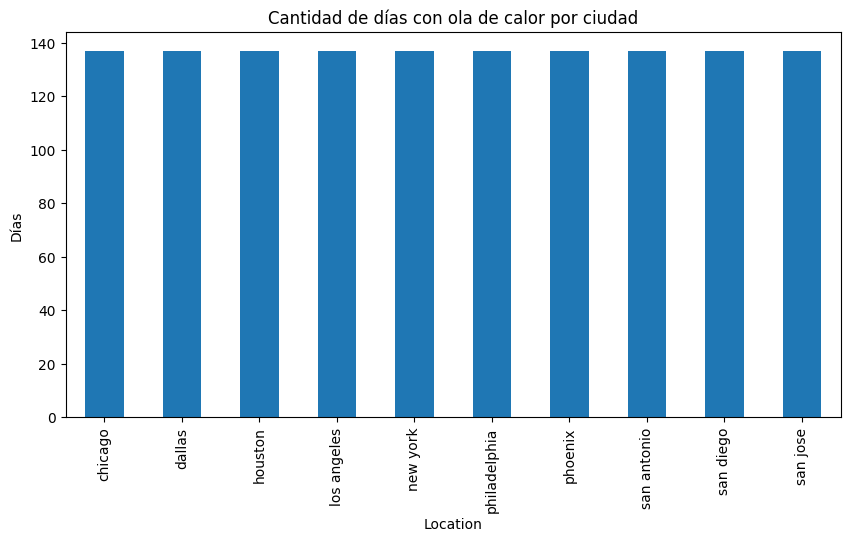

In [104]:
# === Visualización 3: días de olas de calor por ciudad ===
heatwave_days.groupby(level='Location')['Temperature_C'].count().plot(
    kind='bar',
    title='Cantidad de días con ola de calor por ciudad',
    ylabel='Días',
    figsize=(10,5)
)
plt.show()

In [105]:
# === Mostrar resultados en pantalla ===

print("Días con temperatura >30°C (primeros 10):")
print(hot_days.head(10))

print("\nDías que forman parte de una ola de calor ≥3 días (primeros 10):")
print(heatwave_days.head(10))

# === Ejemplos de análisis por ciudad, fecha y combinación ===
chicago = daily.loc['chicago']
print("\nTodas las fechas de Chicago:")
print(chicago.head(5))  # primeras 5 filas

print("\nPromedio de temperatura en Chicago:", chicago['Temperature_C'].mean())
print("Máxima temperatura en Chicago:", chicago['Temperature_C'].max())
print("Mínima temperatura en Chicago:", chicago['Temperature_C'].min())

print("\nDías con temperatura >30°C en Chicago:")
print(chicago[chicago['Temperature_C'] > 30].head(5))

# Temperatura de Chicago el 2024-01-02
print("\nTemperatura de Chicago el 2024-01-02:")
print(daily.loc[('chicago','2024-01-02')])

Días con temperatura >30°C (primeros 10):
                     Temperature_C  Humidity_pct  Precipitation_mm  \
Location Date                                                        
chicago  2024-01-01          39.99         60.92           3612.84   
         2024-01-02          39.95         59.68           3953.83   
         2024-01-03          39.73         59.18           3716.29   
         2024-01-04          39.87         58.62           3560.17   
         2024-01-05          39.96         59.51           3598.53   
         2024-01-06          39.98         59.29           3591.37   
         2024-01-07          39.88         59.96           3380.20   
         2024-01-08          39.97         60.72           3687.28   
         2024-01-09          39.94         59.62           3488.04   
         2024-01-10          39.97         59.25           3461.70   

                     Wind_Speed_kmh  
Location Date                        
chicago  2024-01-01           15.23  
   

In [107]:
# de aca para abajo es codigo repetido

In [108]:
# == ¿Cómo optimiza el análisis esta estructura? ==

# El índice jerárquico (en este caso, daily) permite:

# 🔹 Análisis por ciudad
# Permite estudiar tendencias diarias, mensuales o estacionales.
# Rolling averages

# 🔹Análisis por fecha
# Ver qué ciudad estuvo más caliente
# Comparar humedad el mismo día
# Permite comparar rápidamente condiciones meteorológicas entre ciudades.

# 🔹 Agrupar efiente y fácilmente
# df.groupby(level='Location')['Temperature'].mean()
# → Promedio de temperatura por ciudad sin filtros complejos..

# 📌 El MultiIndex: organiza los datos de forma natural, facilita slicing, filtros y agregaciones, y hace el código más limpio y eficiente.

In [109]:
#Análisis por ciudad

#todas las fechas de Chicago
print("Todas las fechas de Chicago:")
print(daily.loc['chicago'])

# estadísticas
print("\nPromedio de temperatura en Chicago:", daily.loc['chicago']['Temperature_C'].mean())
print("Máxima temperatura en Chicago:", daily.loc['chicago']['Temperature_C'].max())
print("Mínima temperatura en Chicago:", daily.loc['chicago']['Temperature_C'].min())

# Filtrar días calurosos solo en Chicago
print("\nDías con temperatura >30°C en Chicago:")
print(daily.loc['chicago'][daily.loc['chicago']['Temperature_C'] > 30])



Todas las fechas de Chicago:
            Temperature_C  Humidity_pct  Precipitation_mm  Wind_Speed_kmh
Date                                                                     
2024-01-01          39.99         60.92           3612.84           15.23
2024-01-02          39.95         59.68           3953.83           15.32
2024-01-03          39.73         59.18           3716.29           15.38
2024-01-04          39.87         58.62           3560.17           14.45
2024-01-05          39.96         59.51           3598.53           15.07
...                   ...           ...               ...             ...
2024-05-14          39.91         60.33           3639.48           14.62
2024-05-15          40.00         59.73           3810.69           15.08
2024-05-16          39.94         61.26           3515.26           14.97
2024-05-17          39.97         59.54           3947.60           15.12
2024-05-18          39.97         59.82           2968.76           15.22

[139 row

In [110]:
# 🔹Análisis Todas las ciudades en una fecha específica
daily.xs('2024-01-01', level='Date')


,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
Location,,,,
chicago,39.99,60.92,3612.84,15.23
dallas,39.96,59.85,3497.29,15.27
houston,39.91,59.16,3719.08,15.03
los angeles,39.94,59.71,3728.41,14.73
new york,40.00,59.88,3602.77,14.65
philadelphia,39.95,59.90,3685.16,14.78
phoenix,39.25,59.77,5601.05,14.51
san antonio,39.95,59.95,3588.39,14.68
san diego,39.84,61.13,3724.44,15.46


In [111]:
#Combinación ciudad + fecha
# Temperatura de Chicago el 2024-01-02
daily.loc[('chicago', '2024-01-01')]


,chicago
,2024-01-01
Temperature_C,39.99
Humidity_pct,60.92
Precipitation_mm,3612.84
Wind_Speed_kmh,15.23
